pl_name
hostname
default_flag
sy_snum
sy_pnum
discoverymethod
disc_year
disc_facility
soltype
pl_controv_flag
pl_refname
pl_orbper
pl_orbpererr1
pl_orbpererr2
pl_orbperlim
pl_orbsmax
pl_orbsmaxerr1
pl_orbsmaxerr2
pl_orbsmaxlim
pl_rade
pl_radeerr1
pl_radeerr2
pl_radelim
pl_radj
pl_radjerr1
pl_radjerr2
pl_radjlim
pl_bmasse
pl_bmasseerr1
pl_bmasseerr2
pl_bmasselim
pl_bmassj
pl_bmassjerr1
pl_bmassjerr2
pl_bmassjlim
pl_bmassprov
pl_orbeccen
pl_orbeccenerr1
pl_orbeccenerr2
pl_orbeccenlim
pl_insol
pl_insolerr1
pl_insolerr2
pl_insollim
pl_eqt
pl_eqterr1
pl_eqterr2
pl_eqtlim
ttv_flag
st_refname
st_spectype
st_teff
st_tefferr1
st_tefferr2
st_tefflim
st_rad
st_raderr1
st_raderr2
st_radlim
st_mass
st_masserr1
st_masserr2
st_masslim
st_met
st_meterr1
st_meterr2
st_metlim
st_metratio
st_logg
st_loggerr1
st_loggerr2
st_logglim
sy_refname
rastr
ra
decstr
dec
sy_dist
sy_disterr1
sy_disterr2
sy_vmag
sy_vmagerr1
sy_vmagerr2
sy_kmag
sy_kmagerr1
sy_kmagerr2
sy_gaiamag
sy_gaiamagerr1
sy_gaiamagerr2
rowupdat

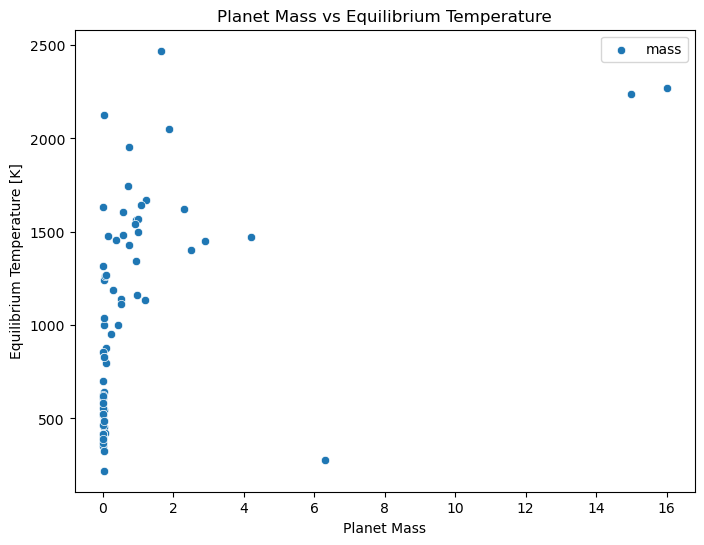

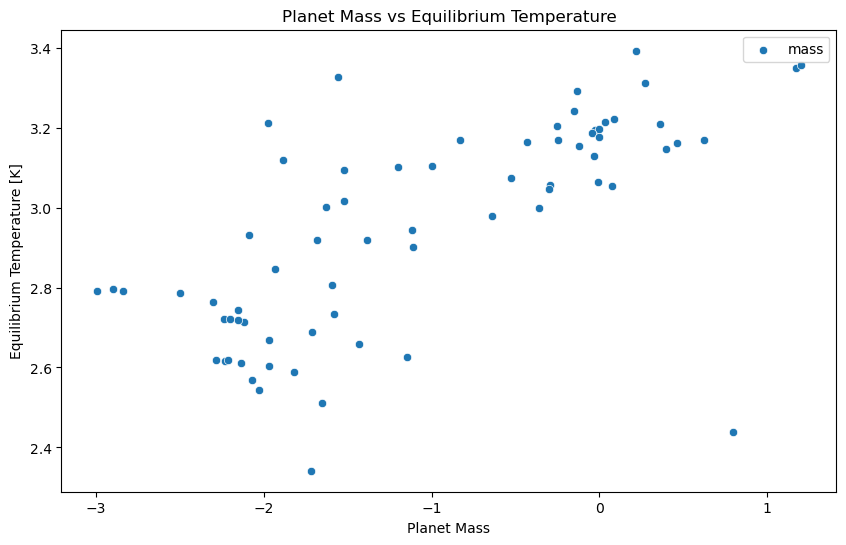

pl_name                eps Ind A b
hostname                 eps Ind A
discoverymethod    Radial Velocity
st_spectype                   K5 V
pl_eqt                       275.0
pl_bmassj                     6.31
log_mass                  0.800029
log_eqt                   2.439333
Name: 581, dtype: object


In [5]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd 
import seaborn as sns
df = pd.read_csv('exoplanet_data.csv', comment = "#")
df.shape #(583, 92) there are 583 rows and 92 columns
for col in df.columns:
    print(col)
# have no idea what sy_snum, sy_pnum, default_flag, pl_orbsmaxlin, and pl_orbsmax
# Planet Name - pl_name - Planet name most commonly used in the literature
# Host Name - hostname - Stellar name most commonly used in the literature
# Discovery Method - discoverymet - Method by which the planet was first identified
# Spectral Type - st_spectype - Classification of the star based on their spectral characteristics following the Morgan-Keenan system
# Equilibrium Temperature [K] - pl_eqt - The equilibrium temperature of the planet as modeled by a black body heated only by its host star, or for directly imaged planets, the effective temperature of the planet required to match the measured luminosity if the planet were a black body.
# Planet Mass or Mass*sin(i) [Jupiter Mass] - pl_bmassj - Best planet mass estimate available, in order of preference: Mass, M*sin(i)/sin(i), or M*sin(i), depending on availability, and measured in Jupiter masses.
keep_columns = ['pl_name', 'hostname', 'discoverymethod', 'st_spectype', 'pl_eqt', 'pl_bmassj'] 
smaller_df = df[keep_columns]
smaller_df = smaller_df.dropna(axis=0)
smaller_df.shape #(583, 6) there are 583 rows and 6 columns
print(smaller_df.head())
print(smaller_df.tail())
for col in smaller_df.columns:
    print(col)
smaller_df['discoverymethod'].value_counts()
# the different methods are transit, radial velocity, microlensing, imaging, transit timig variations, eclipse timing variations, disk kinematics 
# transit - 392, radial velocity - 118, microlensing - 61, imaging - 6, transit timig variations - 3, eclipse timing variations - 2, disk kinematics - 1
# transit has the most while disk kinematics has the least 
# transit - measuring the slight, periodic dimming of a star's light as a planet passes in front of it.
plt.figure(figsize=(8, 6))
sns.scatterplot(data=smaller_df, x='pl_bmassj', y='pl_eqt', label = "mass")
plt.title('Planet Mass vs Equilibrium Temperature')
plt.xlabel('Planet Mass')
plt.ylabel('Equilibrium Temperature [K]')
plt.legend()
plt.show()
smaller_df['log_mass'] = np.log10(smaller_df['pl_bmassj'])
smaller_df['log_eqt'] = np.log10(smaller_df['pl_eqt'])
plt.figure(figsize=(10, 6))
sns.scatterplot(data=smaller_df, x='log_mass', y='log_eqt', label = "mass")
plt.title('Planet Mass vs Equilibrium Temperature')
plt.xlabel('Planet Mass')
plt.ylabel('Equilibrium Temperature [K]')
plt.legend()
plt.show()
# the exoplanets are more likely to be small.
cold_massive = smaller_df[smaller_df['pl_bmassj'] > 5].sort_values('pl_eqt').iloc[0]
print(cold_massive)
# title is A temperate super-Jupiter imaged with JWST in the mid-infrared
# imaging of a "cold super-Jupiter" using the James Webb Space Telescope (JWST). It is one of the coldest exoplanets ever imaged.
# yes it matches the exoplanet eps Ind A
# special because it is a cold exoplanet
# it closely matches it